# Systematic Trading Strategy Evaluation — Walk-Forward, Multi-Strategy, Statistically Tested

Two independent long-only strategies backtested on 5 NSE large-caps and compared for robustness:

1. **SMA Crossover** (trend-following) — long when short SMA > long SMA
2. **RSI Mean-Reversion** — long when RSI signals oversold, exit on RSI recovery

**What makes this a rigorous evaluation, not a single lucky backtest:**
- **Walk-forward validation** — 4 sequential, non-overlapping test folds with an expanding training window (not one arbitrary train/test split)
- **Parameters re-optimized per fold** on train data only, every time, then evaluated on unseen data
- **Transaction costs** charged on every trade
- **Statistical significance testing** — a t-test on whether mean daily strategy return is distinguishable from zero, plus a bootstrap confidence interval on the Sharpe ratio, computed per fold
- **Two strategies compared head-to-head** for which is more robust out-of-sample, not just which backtested better once

Data source: live daily price history from Yahoo Finance via `yfinance`.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf

plt.rcParams["figure.figsize"] = (10, 5)


## 2. Configuration

In [2]:
TICKERS = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS"]
START_DATE = "2019-01-01"
END_DATE = None

N_FOLDS = 4
INITIAL_TRAIN_FRAC = 0.4     # first 40% of history is the initial training window
WARMUP_DAYS = 200            # extra days carried into each test fold so SMA/RSI are valid from day 1

SMA_SHORT_RANGE = [10, 20, 30]
SMA_LONG_RANGE = [50, 100, 150]
RSI_ENTRY_RANGE = [20, 25, 30, 35]
RSI_PERIOD = 14
RSI_EXIT = 50

TRANSACTION_COST_BPS = 10
RISK_FREE_RATE = 0.06
TRADING_DAYS = 252
N_BOOTSTRAP = 1000


## 3. Download and align data

Each ticker is downloaded independently and can have slightly different trading-day gaps
(exchange holidays, listing differences). We align all 5 to their **common** date index so every
fold and every comparison uses exactly the same calendar days across stocks.

In [3]:
def download_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    if data.empty:
        raise ValueError(f"No data returned for {ticker}.")
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    return data[["Close"]].dropna()

raw_data = {}
for ticker in TICKERS:
    try:
        raw_data[ticker] = download_data(ticker, START_DATE, END_DATE)
        print(f"[OK] {ticker}: {len(raw_data[ticker])} days")
    except Exception as e:
        print(f"[SKIPPED] {ticker}: {e}")

common_index = None
for df in raw_data.values():
    common_index = df.index if common_index is None else common_index.intersection(df.index)

price_data = {t: df.loc[common_index].sort_index() for t, df in raw_data.items()}
print(f"\nAligned to {len(common_index)} common trading days "
      f"({common_index.min().date()} to {common_index.max().date()})")


[OK] RELIANCE.NS: 1882 days
[OK] TCS.NS: 1882 days
[OK] HDFCBANK.NS: 1882 days
[OK] INFY.NS: 1882 days
[OK] ICICIBANK.NS: 1882 days

Aligned to 1882 common trading days (2019-01-01 to 2026-08-10)


## 4. Walk-forward folds

Expanding-window walk-forward: fold 0 trains on the first 40% of history and tests on the next chunk;
fold 1 trains on everything up to (and including) fold 0's test period and tests on the next chunk; and so on.
Test periods never overlap and are never seen during that fold's parameter selection.

In [4]:
def generate_folds(n_rows, n_folds=N_FOLDS, initial_train_frac=INITIAL_TRAIN_FRAC):
    initial_train_end = int(n_rows * initial_train_frac)
    remaining = n_rows - initial_train_end
    fold_size = remaining // n_folds
    folds = []
    train_end = initial_train_end
    for i in range(n_folds):
        test_start = train_end
        test_end = test_start + fold_size if i < n_folds - 1 else n_rows
        folds.append((0, train_end, test_start, test_end))
        train_end = test_end
    return folds

FOLDS = generate_folds(len(common_index))
for i, (tr_s, tr_e, te_s, te_e) in enumerate(FOLDS):
    print(f"Fold {i}: train=[{common_index[tr_s].date()} to {common_index[tr_e-1].date()}]  "
          f"test=[{common_index[te_s].date()} to {common_index[te_e-1].date()}]")


Fold 0: train=[2019-01-01 to 2022-01-14]  test=[2022-01-17 to 2023-03-03]
Fold 1: train=[2019-01-01 to 2023-03-03]  test=[2023-03-06 to 2024-05-02]
Fold 2: train=[2019-01-01 to 2024-05-02]  test=[2024-05-03 to 2025-06-20]
Fold 3: train=[2019-01-01 to 2025-06-20]  test=[2025-06-23 to 2026-08-10]


## 5. Strategy 1 — SMA Crossover (trend-following)

In [5]:
def sma_signal(df, short_window, long_window):
    df = df.copy()
    df["SMA_short"] = df["Close"].rolling(short_window, min_periods=short_window).mean()
    df["SMA_long"] = df["Close"].rolling(long_window, min_periods=long_window).mean()
    df["signal"] = 0
    valid = df["SMA_short"].notna() & df["SMA_long"].notna()
    df.loc[valid, "signal"] = np.where(df.loc[valid, "SMA_short"] > df.loc[valid, "SMA_long"], 1, 0)
    df["position_change"] = df["signal"].diff().fillna(0)
    return df


## 6. Strategy 2 — RSI Mean-Reversion

In [6]:
def rsi_signal(df, period=RSI_PERIOD, entry=30, exit_=RSI_EXIT):
    df = df.copy()
    delta = df["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period, min_periods=period).mean()
    avg_loss = loss.rolling(period, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    df["RSI"] = 100 - (100 / (1 + rs))

    # go long when RSI signals oversold, exit once it recovers past `exit_` — hold in between
    raw = pd.Series(np.nan, index=df.index)
    raw[df["RSI"] < entry] = 1
    raw[df["RSI"] > exit_] = 0
    df["signal"] = raw.ffill().fillna(0).astype(int)
    df["position_change"] = df["signal"].diff().fillna(0)
    return df


## 7. Backtest — with transaction costs

`signal.shift(1)` avoids lookahead bias in both strategies. Cost is charged in basis points
on every day a trade actually fires.

In [7]:
def backtest(df, cost_bps=TRANSACTION_COST_BPS, initial_capital=100_000.0):
    df = df.copy()
    df["daily_return"] = df["Close"].pct_change()
    gross = df["signal"].shift(1).fillna(0) * df["daily_return"]
    cost = (df["position_change"].abs() > 0) * (cost_bps / 10_000)
    df["strategy_return"] = gross - cost
    df["cumulative_market_return"] = (1 + df["daily_return"].fillna(0)).cumprod()
    df["cumulative_strategy_return"] = (1 + df["strategy_return"].fillna(0)).cumprod()
    df["portfolio_value"] = initial_capital * df["cumulative_strategy_return"]
    return df


## 8. Performance metrics

In [8]:
def compute_metrics(df, risk_free_rate=RISK_FREE_RATE, trading_days=TRADING_DAYS):
    r = df["strategy_return"].dropna()
    if len(r) == 0 or r.std() == 0:
        return {"Sharpe Ratio": None, "Total Return (%)": None, "Max Drawdown (%)": None}
    total_return = df["cumulative_strategy_return"].iloc[-1] - 1
    ann_vol = r.std(ddof=0) * np.sqrt(trading_days)
    ann_return = r.mean() * trading_days
    sharpe = (ann_return - risk_free_rate) / ann_vol if ann_vol > 0 else None
    cum = df["cumulative_strategy_return"]
    dd = ((cum - cum.cummax()) / cum.cummax()).min()
    return {
        "Total Return (%)": round(total_return * 100, 2),
        "Sharpe Ratio": round(sharpe, 3) if sharpe is not None else None,
        "Max Drawdown (%)": round(dd * 100, 2),
    }


## 9. Statistical significance testing

Two checks on every out-of-sample fold:
- **One-sample t-test**: is the mean daily strategy return distinguishable from zero? (`p < 0.05` = yes)
- **Bootstrap 95% confidence interval on the annualized Sharpe ratio**: resample daily returns
  with replacement 1,000 times and take the 2.5th/97.5th percentiles. If the interval includes 0,
  the Sharpe ratio isn't reliably different from "no edge" given the amount of data available.

In [9]:
def significance_test(strategy_returns, n_bootstrap=N_BOOTSTRAP, seed=42):
    r = strategy_returns.dropna().values
    if len(r) < 30 or r.std() == 0:
        return {"t_stat": None, "p_value": None, "sharpe_ci_low": None, "sharpe_ci_high": None}
    t_stat, p_value = stats.ttest_1samp(r, popmean=0)
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_bootstrap):
        s = rng.choice(r, size=len(r), replace=True)
        if s.std() > 0:
            boots.append((s.mean() * TRADING_DAYS - RISK_FREE_RATE) / (s.std() * np.sqrt(TRADING_DAYS)))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return {"t_stat": round(t_stat, 3), "p_value": round(p_value, 4),
            "sharpe_ci_low": round(lo, 3), "sharpe_ci_high": round(hi, 3)}


## 10. Walk-forward evaluation engine

For each fold: sweep the parameter grid on **train data only**, pick the best by train Sharpe,
then apply those exact parameters to that fold's **test data** (data never touched during selection).
`WARMUP_DAYS` of train data are carried into the test window purely so the SMA/RSI have enough
history to be valid on day 1 of the test period — no test-period data leaks into parameter selection.

In [10]:
def walkforward_strategy(price_df, folds, param_grid, signal_fn, cost_bps=TRANSACTION_COST_BPS, warmup=WARMUP_DAYS):
    fold_rows = []
    last_test_df = None
    for fold_i, (tr_s, tr_e, te_s, te_e) in enumerate(folds):
        train = price_df.iloc[tr_s:tr_e]
        test = price_df.iloc[te_s:te_e]

        best_sharpe, best_params = -np.inf, param_grid[0]
        for params in param_grid:
            d = backtest(signal_fn(train, **params), cost_bps=cost_bps)
            m = compute_metrics(d)
            if m["Sharpe Ratio"] is not None and m["Sharpe Ratio"] > best_sharpe:
                best_sharpe, best_params = m["Sharpe Ratio"], params

        context = pd.concat([train.tail(warmup), test])
        signal_df = signal_fn(context, **best_params)
        test_only = signal_df.loc[test.index]
        d_test = backtest(test_only, cost_bps=cost_bps)
        m_test = compute_metrics(d_test)
        sig = significance_test(d_test["strategy_return"])
        last_test_df = d_test

        fold_rows.append({
            "fold": fold_i, "params": str(best_params),
            "test_sharpe": m_test["Sharpe Ratio"], "test_return_pct": m_test["Total Return (%)"],
            "test_max_dd_pct": m_test["Max Drawdown (%)"], "p_value": sig["p_value"],
            "sharpe_ci_low": sig["sharpe_ci_low"], "sharpe_ci_high": sig["sharpe_ci_high"],
        })
    return pd.DataFrame(fold_rows), last_test_df


## 11. Run walk-forward for both strategies, across all 5 stocks

In [11]:
FOLDS = generate_folds(len(common_index))

sma_grid = [{"short_window": s, "long_window": l} for s in SMA_SHORT_RANGE for l in SMA_LONG_RANGE if s < l]
rsi_grid = [{"entry": e, "period": RSI_PERIOD, "exit_": RSI_EXIT} for e in RSI_ENTRY_RANGE]

all_results = []
last_fold_dfs = {}   # for equity-curve plotting later: {(ticker, strategy): df}

for ticker, df in price_data.items():
    sma_res, sma_last = walkforward_strategy(df, FOLDS, sma_grid, sma_signal)
    sma_res["ticker"], sma_res["strategy"] = ticker, "SMA"
    all_results.append(sma_res)
    last_fold_dfs[(ticker, "SMA")] = sma_last

    rsi_res, rsi_last = walkforward_strategy(df, FOLDS, rsi_grid, rsi_signal)
    rsi_res["ticker"], rsi_res["strategy"] = ticker, "RSI"
    all_results.append(rsi_res)
    last_fold_dfs[(ticker, "RSI")] = rsi_last

    print(f"[DONE] {ticker}")

results = pd.concat(all_results, ignore_index=True)
results.head(10)


[DONE] RELIANCE.NS
[DONE] TCS.NS
[DONE] HDFCBANK.NS
[DONE] INFY.NS
[DONE] ICICIBANK.NS


,fold,params,test_sharpe,test_return_pct,test_max_dd_pct,p_value,sharpe_ci_low,sharpe_ci_high,ticker,strategy
0,0,"{'short_window': 10, 'long_window': 50}",-1.757,-22.67,-26.70,0.1477,-3.604,0.129,RELIANCE.NS,SMA
1,1,"{'short_window': 10, 'long_window': 100}",0.852,22.69,-11.71,0.1970,-1.053,2.543,RELIANCE.NS,SMA
2,2,"{'short_window': 10, 'long_window': 50}",-0.475,-3.52,-22.39,0.9065,-2.331,1.456,RELIANCE.NS,SMA
3,3,"{'short_window': 20, 'long_window': 50}",-1.538,-12.42,-17.24,0.2906,-3.357,0.297,RELIANCE.NS,SMA
4,0,"{'entry': 35, 'period': 14, 'exit_': 50}",0.000,5.33,-17.48,0.6996,-1.963,1.946,RELIANCE.NS,RSI
5,1,"{'entry': 35, 'period': 14, 'exit_': 50}",0.501,11.63,-3.74,0.2018,-1.445,2.071,RELIANCE.NS,RSI
6,2,"{'entry': 35, 'period': 14, 'exit_': 50}",0.656,16.56,-13.22,0.2414,-1.255,2.376,RELIANCE.NS,RSI
7,3,"{'entry': 35, 'period': 14, 'exit_': 50}",0.071,7.08,-7.49,0.5683,-1.928,2.016,RELIANCE.NS,RSI
8,0,"{'short_window': 20, 'long_window': 100}",-1.070,-11.58,-17.76,0.4830,-2.912,0.802,TCS.NS,SMA
9,1,"{'short_window': 30, 'long_window': 100}",-0.058,4.05,-9.53,0.7578,-2.045,1.779,TCS.NS,SMA


## 12. Aggregate results — is either strategy reliably good?

In [12]:
agg = results.groupby("strategy").agg(
    mean_sharpe=("test_sharpe", "mean"),
    std_sharpe=("test_sharpe", "std"),
    pct_folds_positive=("test_sharpe", lambda x: round((x > 0).mean() * 100, 1)),
    mean_p_value=("p_value", "mean"),
    pct_significant_folds=("p_value", lambda x: round((x < 0.05).mean() * 100, 1)),
)
agg


,mean_sharpe,std_sharpe,pct_folds_positive,mean_p_value,pct_significant_folds
strategy,,,,,
RSI,-0.25780,0.734540,40.0,0.511415,0.0
SMA,-0.69795,1.068662,30.0,0.407690,0.0


**How to read this table:**
- `mean_sharpe` / `std_sharpe` — average and spread of out-of-sample Sharpe across all 20 ticker-fold combinations (5 stocks × 4 folds) per strategy. A high std relative to the mean means the result is inconsistent across time periods and stocks — a warning sign, not a footnote.
- `pct_folds_positive` — how often the strategy actually beat "doing nothing" out-of-sample. Below 50% means it lost more often than it won.
- `pct_significant_folds` — the % of ticker-folds where the t-test found the strategy's daily return distinguishable from zero (`p < 0.05`). Low values here mean most of the observed edge (or lack of it) is statistically indistinguishable from noise given the sample size — an honest caveat, not a flaw.

## 13. Visualization 1 — Distribution of out-of-sample Sharpe ratios (SMA vs RSI)

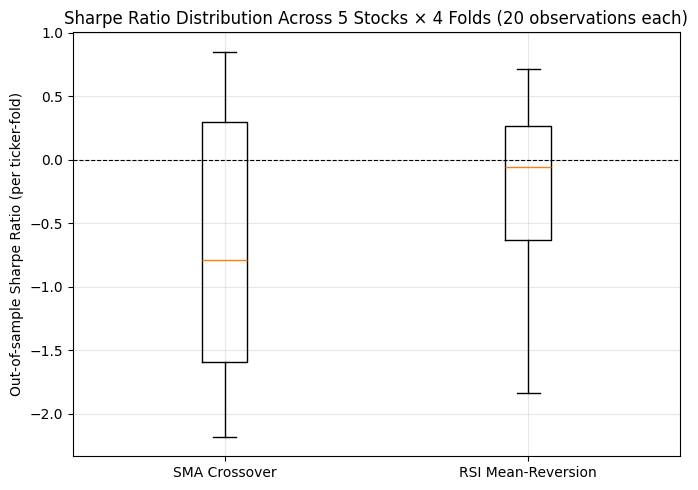

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
data_to_plot = [results[results["strategy"] == s]["test_sharpe"].dropna().values for s in ["SMA", "RSI"]]
ax.boxplot(data_to_plot, tick_labels=["SMA Crossover", "RSI Mean-Reversion"])
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Out-of-sample Sharpe Ratio (per ticker-fold)")
ax.set_title("Sharpe Ratio Distribution Across 5 Stocks × 4 Folds (20 observations each)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Visualization 2 — Bootstrap Sharpe confidence intervals by fold

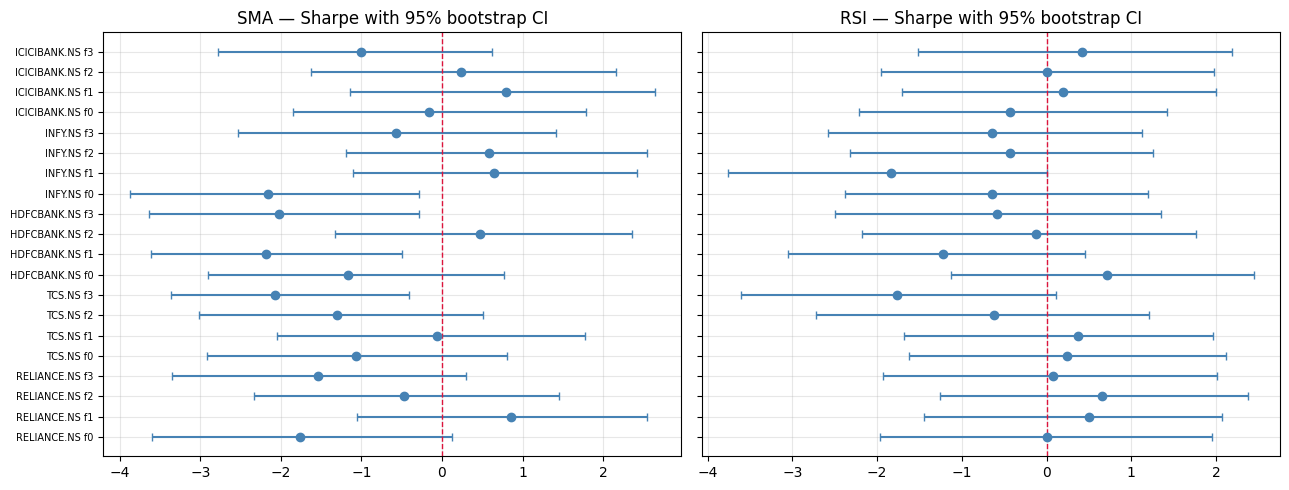

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, strat in zip(axes, ["SMA", "RSI"]):
    sub = results[results["strategy"] == strat].copy()
    sub["label"] = sub["ticker"] + " f" + sub["fold"].astype(str)
    y = np.arange(len(sub))
    ax.errorbar(sub["test_sharpe"], y,
                xerr=[sub["test_sharpe"] - sub["sharpe_ci_low"], sub["sharpe_ci_high"] - sub["test_sharpe"]],
                fmt="o", capsize=3, color="steelblue")
    ax.axvline(0, color="crimson", linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["label"], fontsize=7)
    ax.set_title(f"{strat} — Sharpe with 95% bootstrap CI")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Visualization 3 — Stitched out-of-sample equity curve (last fold, all stocks)

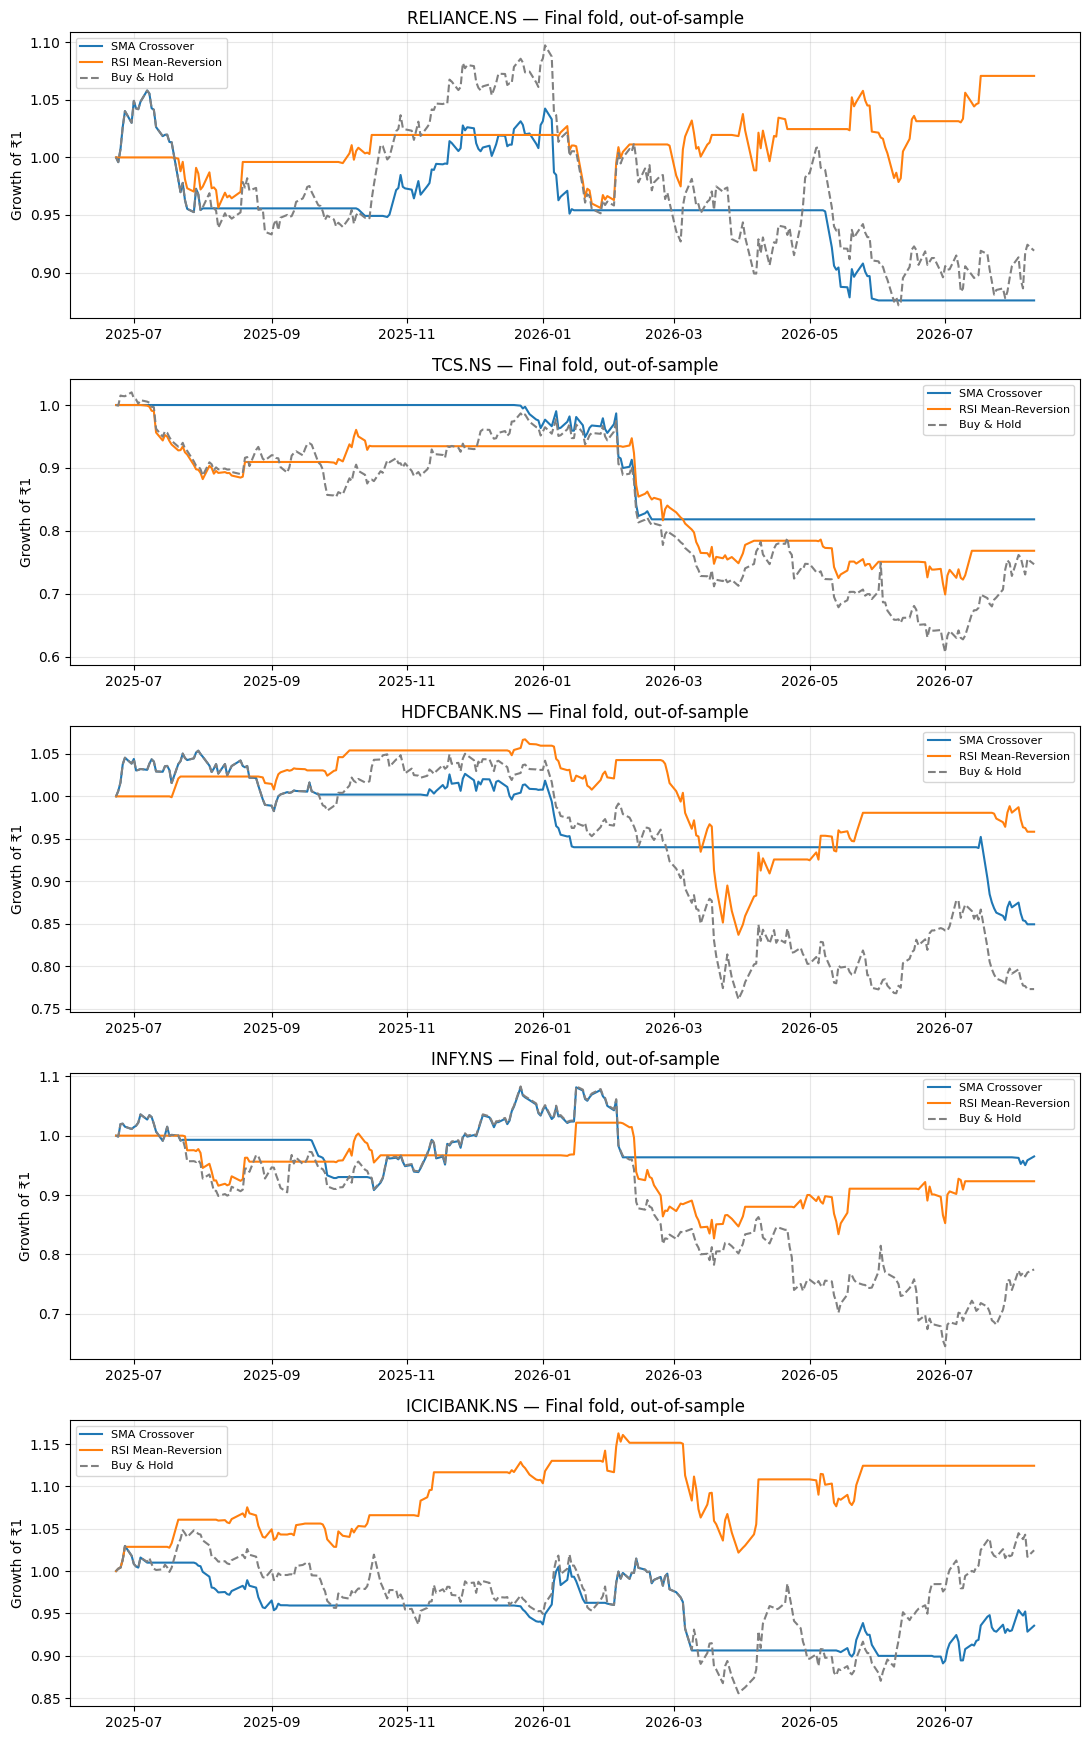

In [15]:
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(11, 3.5 * len(TICKERS)))
for ax, ticker in zip(axes, price_data.keys()):
    d_sma = last_fold_dfs[(ticker, "SMA")]
    d_rsi = last_fold_dfs[(ticker, "RSI")]
    ax.plot(d_sma.index, d_sma["cumulative_strategy_return"], label="SMA Crossover")
    ax.plot(d_rsi.index, d_rsi["cumulative_strategy_return"], label="RSI Mean-Reversion")
    ax.plot(d_sma.index, d_sma["cumulative_market_return"], label="Buy & Hold", linestyle="--", color="gray")
    ax.set_title(f"{ticker} — Final fold, out-of-sample")
    ax.set_ylabel("Growth of ₹1")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 16. Visualization 4 — Mean out-of-sample Sharpe by stock and strategy

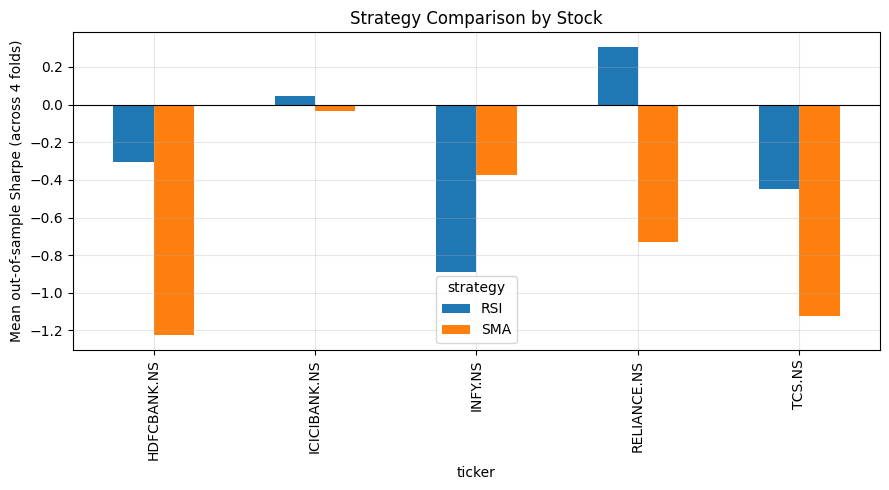

In [16]:
pivot = results.pivot_table(index="ticker", columns="strategy", values="test_sharpe", aggfunc="mean")
fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean out-of-sample Sharpe (across 4 folds)")
ax.set_title("Strategy Comparison by Stock")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 17. Visualization 5 — Return correlation across stocks (last fold)

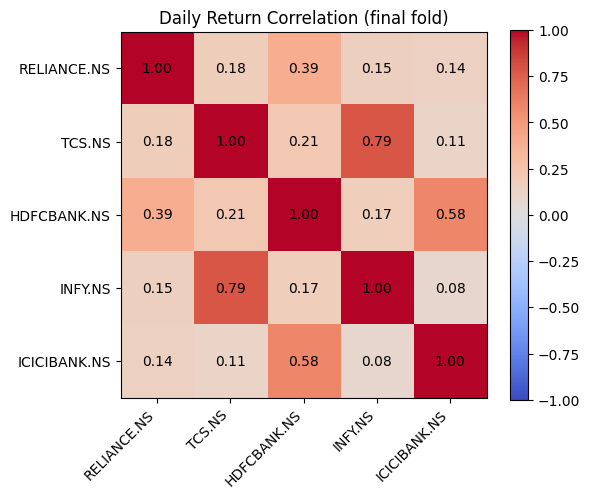

In [17]:
returns_matrix = pd.DataFrame({t: last_fold_dfs[(t, "SMA")]["daily_return"] for t in price_data.keys()})
corr = returns_matrix.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right"); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.colorbar(im)
plt.title("Daily Return Correlation (final fold)")
plt.tight_layout()
plt.show()


## 18. Save results

In [18]:
results.to_csv("walkforward_results.csv", index=False)
agg.to_csv("strategy_comparison_summary.csv")
print("Saved walkforward_results.csv and strategy_comparison_summary.csv")


Saved walkforward_results.csv and strategy_comparison_summary.csv


## 19. Interpretation

*(Fill in with your actual numbers after running — this is the part you should be able to say out loud in an interview without notes.)*

1. **Which strategy is more robust, not just which backtested higher?** Compare `mean_sharpe` vs `std_sharpe` for SMA and RSI in the section 12 table — a strategy with a higher mean but much higher std is less trustworthy than one with a lower but more consistent mean.
2. **How much of this is statistically real?** Look at `pct_significant_folds` — if it's low (e.g., under 30-40%), be upfront that most individual fold results can't be distinguished from noise at conventional significance levels, even if the average looks directionally interesting. That's a mature, correct thing to say, not a weakness to hide.
3. **Do the bootstrap CIs in section 14 cross zero?** If most of them do, that's the same signal as (2) from a different angle — visually, does the whisker for each ticker-fold cross the red dashed line?
4. **Does either strategy beat buy-and-hold consistently** (section 15/16), or does performance depend heavily on which stock and which time window you look at?
5. **One concrete next step** if you had another week — e.g., testing on a different asset class to see if either edge is asset-specific, or combining both signals (only go long when SMA and RSI agree) to see if that reduces the variance seen in section 13.